In [37]:
import os
import pandas as pd

# Directory containing the .flow files
directory = 'CTU_13/4_rbot'

# List to store individual dataframes
dataframes = []

# Loop through each file in the directory
for filename in os.listdir(directory):
    if filename.endswith('.flow'):
        # Read the file into a dataframe
        df = pd.read_csv(os.path.join(directory, filename))  # Adjust the reading method if necessary
        
        # Add a label column with the filename (without extension) as the label value
        #df['label'] = os.path.splitext(filename)[0]
        
        # Append the dataframe to the list
        dataframes.append(df)

# Concatenate all dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=True)

combined_df.rename(columns={'Label': 'label'}, inplace=True)

# Remove rows where 'label' contains 'background'
#combined_df = combined_df[~combined_df['Label'].str.contains('background', case=False, na=False)]

# Update the 'label' column: 'Botnet' -> 1, 'Normal' -> 0
#combined_df['label'] = combined_df['label'].apply(lambda x: 1 if 'Botnet' in x else (0 if 'Normal' in x else x))

# Update the 'label' column: 'Botnet' -> 1, 'Normal' -> 0, 'Background' -> 0
combined_df['label'] = combined_df['label'].apply(lambda x: 1 if 'Botnet' in x else (0 if 'Normal' in x or 'Background' in x else x))

# Optionally reset the index if needed
combined_df.reset_index(drop=True, inplace=True)

# Display the combined dataframe
print(combined_df)


         TotBytes  SrcBytes  DstBytes  SrcGap  DstGap  sMeanPktSz  dMeanPktSz  \
0             252       132       120     0.0     0.0        66.0        60.0   
1             252       132       120     0.0     0.0        66.0        60.0   
2             252       132       120     0.0     0.0        66.0        60.0   
3             252       132       120     0.0     0.0        66.0        60.0   
4             252       132       120     0.0     0.0        66.0        60.0   
...           ...       ...       ...     ...     ...         ...         ...   
1121071       132        72        60     NaN     NaN        72.0        60.0   
1121072       124        62        62     0.0     0.0        62.0        62.0   
1121073       148        74        74     0.0     0.0        74.0        74.0   
1121074       191       191         0     NaN     NaN       191.0         0.0   
1121075        60        60         0     0.0     0.0        60.0         0.0   

         sMaxPktSz  dMaxPkt

In [38]:
import os
import yaml
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import re

def keep_features(df, features_to_keep):
    """
    Drop all columns from the DataFrame except for the specified features.
    
    Parameters:
    - df: pd.DataFrame, the input DataFrame
    - features_to_keep: list, list of column names to retain
    
    Returns:
    - pd.DataFrame with only the specified columns
    """
    # Ensure that the features_to_keep are in the DataFrame
    features_to_keep = [feature for feature in features_to_keep if feature in df.columns]
    
    # Return a DataFrame with only the specified features
    return df[features_to_keep]

# Function to preprocess each dataset
def preprocess_dataset(df):
    # Drop columns that contain only missing values
    df = df.dropna(axis=1, how='all')
    # Separate numeric and non-numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
    
    # Check if DataFrame has either numeric or non-numeric columns
    if not numeric_cols.empty or not non_numeric_cols.empty:
        # Handle missing values for numeric data
        if not numeric_cols.empty:
            imputer_numeric = SimpleImputer(strategy='mean')
            df_numeric = pd.DataFrame(imputer_numeric.fit_transform(df[numeric_cols]), columns=numeric_cols)
        else:
            df_numeric = pd.DataFrame()  # Empty DataFrame for numeric data if no numeric columns exist
        
        # Handle missing values for non-numeric data
        if not non_numeric_cols.empty:
            imputer_non_numeric = SimpleImputer(strategy='most_frequent')
            df_non_numeric = pd.DataFrame(imputer_non_numeric.fit_transform(df[non_numeric_cols]), columns=non_numeric_cols)
            # Convert non-numeric features to one-hot encoding
            encoder = OneHotEncoder(drop='first')
            encoded = encoder.fit_transform(df_non_numeric)
            encoded_df = pd.DataFrame(encoded.toarray(), columns=encoder.get_feature_names_out(non_numeric_cols))
        else:
            encoded_df = pd.DataFrame()  # Empty DataFrame for encoded non-numeric data if no non-numeric columns exist
        
        # Concatenate processed numeric and encoded non-numeric data
        df_preprocessed = pd.concat([df_numeric, encoded_df], axis=1)
        
        '''
        features = [
            'pRetran', 'Max', 'sMeanPktSz', 'SrcRetra', 'PCRatio',
            'SrcWin,SrcLoss', 'DstRate', 'SrcLoad', 'TcpOpt_MwsS  T', 'Load', 'DstLoad', 'TcpRtt', 'Flgs_ e g      ',
            'Flgs_ e d      ', 'Sum', 'AckDat', 'dTtl', 'Min', 'pLoss', 'DstLoss', 'State_S_',
            'Cause_Status', 'Loss', 'StdDev', 'Rate', 'SrcRate', 'IdleTime', 'Dur', 'SrcPkts', 'Flgs_ e s      ',
            'SrcGap', 'DstBytes', 'DstGap', 'sTtl', 'DstWin', 'TotPkts', 'DstPkts', 'Flgs_ e *      ', 'Mean',
            'SrcBytes', 'State__SA', 'TotBytes', 'Cause_Start', 'dMeanPktSz', 'DstRetra', 'SynAck'
        ]
        
        '''
        features = [
            'sTtl', 'AckDat', 'TcpRtt', 'SynAck', 'IdleTime', 'SrcBytes', 
            'DstWin', 'SrcWin', 'TcpOpt_MwsS  T', 'Min', 'Dur', 'pLoss',
            'Flgs_ e s      ', 'State_S_', 'TotPkts', 'DstPkts'
        ]

        # Drop all columns except the ones in features_to_keep
        df_preprocessed = keep_features(df_preprocessed, features)  

        # Scale features
        scaler = MinMaxScaler()
        df_scaled = pd.DataFrame(scaler.fit_transform(df_preprocessed), columns=df_preprocessed.columns)

        return df_scaled
    else:
        return pd.DataFrame()
    
# Step 1: Separate the label column
X = combined_df.drop(columns=['label'])
y = combined_df['label']

pre_df = preprocess_dataset(X)

pre_df['label'] = y

print(len(pre_df.columns))
pre_df['label']

17


0          0
1          0
2          0
3          0
4          0
          ..
1121071    0
1121072    0
1121073    0
1121074    0
1121075    0
Name: label, Length: 1121076, dtype: int64

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
import numpy as np

# Assuming `df` is your DataFrame and 'label' is your target column

# Step 1: Separate features (X) and target (y)
X = pre_df.drop(columns=['label'])  # Drop the label column to get the features
y = pre_df['label']  # Target variable

# Step 2: Initialize the Random Forest Classifier
clf = RandomForestClassifier(n_estimators=10, random_state=42)

# Step 3: Perform cross-validation
cv_results = cross_validate(clf, X, y, cv=5, scoring=['accuracy', 'f1_macro', 'recall_macro'], return_train_score=False)

# Print cross-validation results
print(f"Cross-Validation Accuracy: {np.mean(cv_results['test_accuracy']):.4f} ± {np.std(cv_results['test_accuracy']):.4f}")
print(f"Cross-Validation F1 Score: {np.mean(cv_results['test_f1_macro']):.4f} ± {np.std(cv_results['test_f1_macro']):.4f}")
print(f"Cross-Validation Recall: {np.mean(cv_results['test_recall_macro']):.4f} ± {np.std(cv_results['test_recall_macro']):.4f}")

# Optionally, fit the model on the entire dataset for feature importance
clf.fit(X, y)

# Step 4: Feature Importances
importances = clf.feature_importances_
indices = importances.argsort()[::-1]  # Sort in descending order

# Step 5: Print top 10 feature importances
print("\nTop 10 Feature Importances:")
for i in range(min(10, len(indices))):  # Ensure there are at least 10 features
    print(f"Feature {X.columns[indices[i]]}: {importances[indices[i]]:.4f}")

# If you still want to compute confusion matrix and classification report, you need to split data again and train/test model
# For demonstration purposes, let's use the initial train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Confusion Matrix and Classification Report
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Cross-Validation Accuracy: 0.9993 ± 0.0008
Cross-Validation F1 Score: 0.8737 ± 0.1878
Cross-Validation Recall: 0.8606 ± 0.1854

Top 10 Feature Importances:
Feature sTtl: 0.2843
Feature SrcBytes: 0.2306
Feature SrcWin: 0.1006
Feature State_S_: 0.0973
Feature TotPkts: 0.0820
Feature Dur: 0.0550
Feature Min: 0.0522
Feature IdleTime: 0.0421
Feature DstPkts: 0.0302
Feature pLoss: 0.0118

Confusion Matrix:
[[335512     11]
 [   177    623]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    335523
           1       0.98      0.78      0.87       800

    accuracy                           1.00    336323
   macro avg       0.99      0.89      0.93    336323
weighted avg       1.00      1.00      1.00    336323



In [40]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Read the DataFrame (Replace this with your DataFrame reading code)
df = pre_df

# List of features to compute incremental statistics
feature_list = ['SynAck', 'TcpRtt', 'AckDat']  # Replace with your actual features

import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

def analyze_features(df):
    """
    Analyzes features of the DataFrame based on statistical properties and diversity.
    
    Parameters:
    - df: pandas DataFrame containing the features to analyze.
    
    Returns:
    - stats_df_sorted: pandas DataFrame containing the statistical metrics for each feature, sorted by variance.
    """
    # Separate features (assuming the last column is the target variable)
    X = df.drop(columns=[df.columns[-1]])  # Drop the last column assuming it's the target
    
    # Initialize a DataFrame to hold statistical metrics
    stats_df = pd.DataFrame(index=X.columns)
    
    # Calculate statistical metrics
    stats_df['Mean'] = X.mean()
    stats_df['Median'] = X.median()
    stats_df['StdDev'] = X.std()
    stats_df['Variance'] = X.var()
    stats_df['Range'] = X.max() - X.min()
    stats_df['Skewness'] = X.apply(lambda x: skew(x.dropna()))
    stats_df['Kurtosis'] = X.apply(lambda x: kurtosis(x.dropna()))
    stats_df['Missing Values'] = X.isna().sum()
    
    # Sort by variance (or any other metric you prefer)
    stats_df_sorted = stats_df.sort_values(by='Variance', ascending=False)
    
    # Print the sorted statistics
    print("Feature Statistical Analysis and Diversity:")
    print(stats_df_sorted)
    
    return stats_df_sorted

# Example usage:
# df = pd.read_csv('your_data.csv')  # Load your DataFrame
# stats_df_sorted = analyze_features(df)


# Compute incremental statistics
def compute_incremental_stats(df, features):
    incremental_stats = pd.DataFrame(index=df.index)
    
    for feature in features:
        incremental_stats[f'{feature}_mean'] = df[feature].expanding().mean()
        incremental_stats[f'{feature}_median'] = df[feature].expanding().median()
        incremental_stats[f'{feature}_std'] = df[feature].expanding().std()
        #incremental_stats[f'{feature}_max'] = df[feature].expanding().max()
        #incremental_stats[f'{feature}_min'] = df[feature].expanding().min()
    
    return incremental_stats

# Compute incremental statistics for the features
incremental_stats = compute_incremental_stats(df, feature_list)

# Fill NaN values in incremental statistics with 0
incremental_stats.fillna(0, inplace=True)

# Add incremental statistics to the original DataFrame
df_with_stats = pd.concat([df, incremental_stats], axis=1)

# Standardize the incremental features before clustering
incremental_feature_cols = [col for col in df_with_stats.columns if col.endswith(('mean', 'median', 'std'))]

X = df_with_stats[incremental_feature_cols]

analyze_features(X)

# Fill NaN values in the features (if any) with 0
X.fillna(0, inplace=True)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Perform MiniBatch KMeans clustering
n_clusters = 2
kmeans = MiniBatchKMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to the DataFrame
df_with_stats['cluster'] = clusters

# Remove incremental features
df_final = df_with_stats.drop(columns=incremental_feature_cols)

# Initialize dictionary to store classifiers and results
classifiers = {}
results = {}

# Train and evaluate Random Forest Classifier for each cluster with cross-validation
for i in range(n_clusters):
    # Select data for the current cluster
    cluster_data = df_final[df_final['cluster'] == i]
    
    if len(cluster_data) == 0:
        print(f"Cluster {i} has no data. Skipping.")
        continue
    
    # Separate features and target
    X_cluster = cluster_data.drop(columns=['label'])
    y_cluster = cluster_data['label']
    
    # Check if there is enough data to perform cross-validation
    if len(X_cluster) < 5:
        print(f"Not enough data for cross-validation in cluster {i}.")
        continue
    
    # Initialize Random Forest Classifier
    clf = RandomForestClassifier(n_estimators=10, random_state=42)
    
    # Perform cross-validation
    cv_results = cross_validate(clf, X_cluster, y_cluster, cv=5, scoring=['accuracy', 'f1_macro', 'recall_macro'], return_train_score=False)
    
    # Fit the model on the entire cluster data for confusion matrix
    clf.fit(X_cluster, y_cluster)
    
    # Predict on the same data to compute confusion matrix
    y_pred = clf.predict(X_cluster)
    
    # Compute confusion matrix
    cm = confusion_matrix(y_cluster, y_pred)
    
    # Store the classifier and results
    classifiers[i] = clf
    results[i] = {
        'cv_accuracy': np.mean(cv_results['test_accuracy']),
        'cv_f1_score': np.mean(cv_results['test_f1_macro']),
        'cv_recall': np.mean(cv_results['test_recall_macro']),
        'confusion_matrix': cm,
        'classification_report': classification_report(y_cluster, y_pred)
    }

# Print the results for each cluster
for i, result in results.items():
    print(f"\nCluster {i} - Random Forest Classifier Performance:")
    print(f"Cross-Validation Accuracy: {result['cv_accuracy']:.4f}")
    print(f"Cross-Validation F1 Score: {result['cv_f1_score']:.4f}")
    print(f"Cross-Validation Recall: {result['cv_recall']:.4f}")
    print("\nConfusion Matrix:")
    print(result['confusion_matrix'])
    print("\nClassification Report:")
    print(result['classification_report'])


Feature Statistical Analysis and Diversity:
                   Mean    Median    StdDev      Variance     Range  Skewness  \
SynAck_std     0.001761  0.002073  0.000924  8.534217e-07  0.003215 -0.402412   
TcpRtt_std     0.002161  0.002366  0.000768  5.890617e-07  0.003440 -0.361942   
AckDat_mean    0.000373  0.000380  0.000052  2.717616e-09  0.000430 -1.811779   
TcpRtt_mean    0.000179  0.000185  0.000019  3.723356e-10  0.000194 -2.817077   
SynAck_mean    0.000103  0.000106  0.000010  9.405625e-11  0.000115 -3.215423   
SynAck_median  0.000000  0.000000  0.000000  0.000000e+00  0.000000       NaN   
TcpRtt_median  0.000000  0.000000  0.000000  0.000000e+00  0.000000       NaN   
AckDat_median  0.000000  0.000000  0.000000  0.000000e+00  0.000000       NaN   

                Kurtosis  Missing Values  
SynAck_std     -1.385867               0  
TcpRtt_std     -1.169298               0  
AckDat_mean     5.754650               0  
TcpRtt_mean    11.223523               0  
SynAck_mean

C:\Users\mjf\AppData\Local\Temp\ipykernel_16312\2555680389.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(0, inplace=True)



Cluster 0 - Random Forest Classifier Performance:
Cross-Validation Accuracy: 0.9990
Cross-Validation F1 Score: 0.8748
Cross-Validation Recall: 0.8686

Confusion Matrix:
[[750502    124]
 [    53   2514]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    750626
           1       0.95      0.98      0.97      2567

    accuracy                           1.00    753193
   macro avg       0.98      0.99      0.98    753193
weighted avg       1.00      1.00      1.00    753193


Cluster 1 - Random Forest Classifier Performance:
Cross-Validation Accuracy: 1.0000
Cross-Validation F1 Score: 0.5000
Cross-Validation Recall: 0.5000

Confusion Matrix:
[[367870      0]
 [     9      4]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    367870
           1       1.00      0.31      0.47        13

    accuracy                           1.00    3678

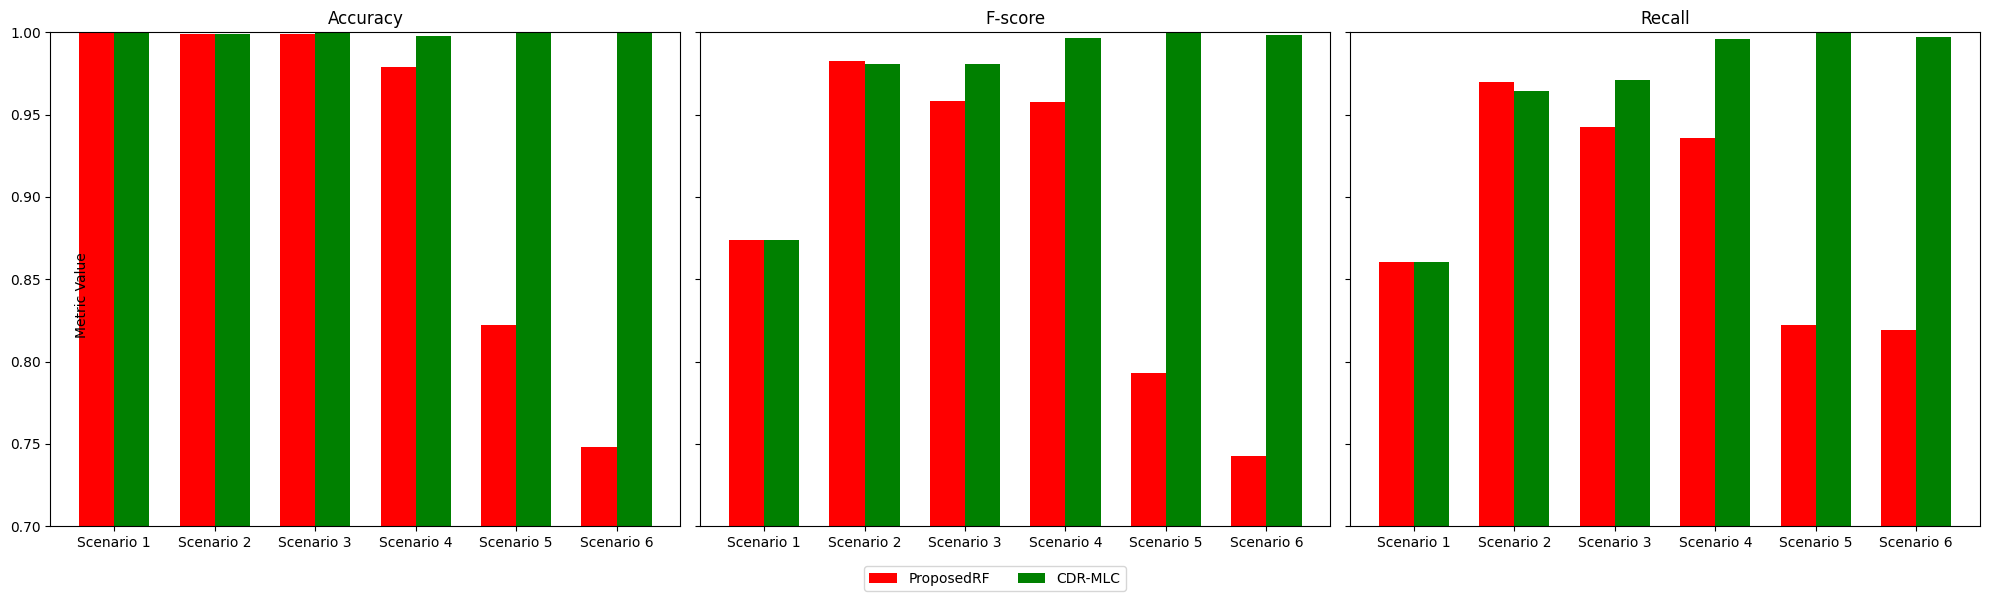

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Data for each scenario
scenarios = ['Scenario 1', 'Scenario 2', 'Scenario 3', 'Scenario 4', 'Scenario 5', 'Scenario 6']
accuracy = {
    'ProposedRF': [0.9993, 0.9992, 0.9989, 0.9790, 0.8221, 0.7481],
    'CDR-MLC': [0.9993, 0.9991, 0.9996, 0.9980, 0.9994, 0.9998]
}
f_score = {
    'ProposedRF': [0.8737, 0.9828, 0.9581, 0.9579, 0.7929, 0.7429],
    'CDR-MLC': [0.8737, 0.9806, 0.9809, 0.9964, 0.9994, 0.9986]
}
recall = {
    'ProposedRF': [0.8606, 0.9697, 0.9427, 0.9358, 0.8224, 0.8191],
    'CDR-MLC': [0.8606, 0.9643, 0.9712, 0.9957, 0.9994, 0.9973]
}
# Plotting all three metrics horizontally
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)  # 1 row, 3 columns layout

# Bar width for each plot
bar_width = 0.35
index = np.arange(len(scenarios))

# Plot for Accuracy
bar1 = axs[0].bar(index, accuracy['ProposedRF'], bar_width, label='ProposedRF', color='red')
bar2 = axs[0].bar(index + bar_width, accuracy['CDR-MLC'], bar_width, label='CDR-MLC', color='green')
axs[0].set_title('Accuracy')
axs[0].set_xticks(index + bar_width / 2)
axs[0].set_xticklabels(scenarios)
axs[0].set_ylim(0.6, 1)

# Plot for F-score
bar1 = axs[1].bar(index, f_score['ProposedRF'], bar_width, label='ProposedRF', color='red')
bar2 = axs[1].bar(index + bar_width, f_score['CDR-MLC'], bar_width, label='CDR-MLC', color='green')
axs[1].set_title('F-score')
axs[1].set_xticks(index + bar_width / 2)
axs[1].set_xticklabels(scenarios)
axs[1].set_ylim(0.6, 1)

# Plot for Recall
bar1 = axs[2].bar(index, recall['ProposedRF'], bar_width, label='ProposedRF', color='red')
bar2 = axs[2].bar(index + bar_width, recall['CDR-MLC'], bar_width, label='CDR-MLC', color='green')
axs[2].set_title('Recall')
axs[2].set_xticks(index + bar_width / 2)
axs[2].set_xticklabels(scenarios)
axs[2].set_ylim(0.7, 1)

# Set y-label for the entire figure
fig.text(0.04, 0.5, 'Metric Value', va='center', rotation='vertical')

# Adding a common legend at the bottom
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to make space for the legend
plt.show()


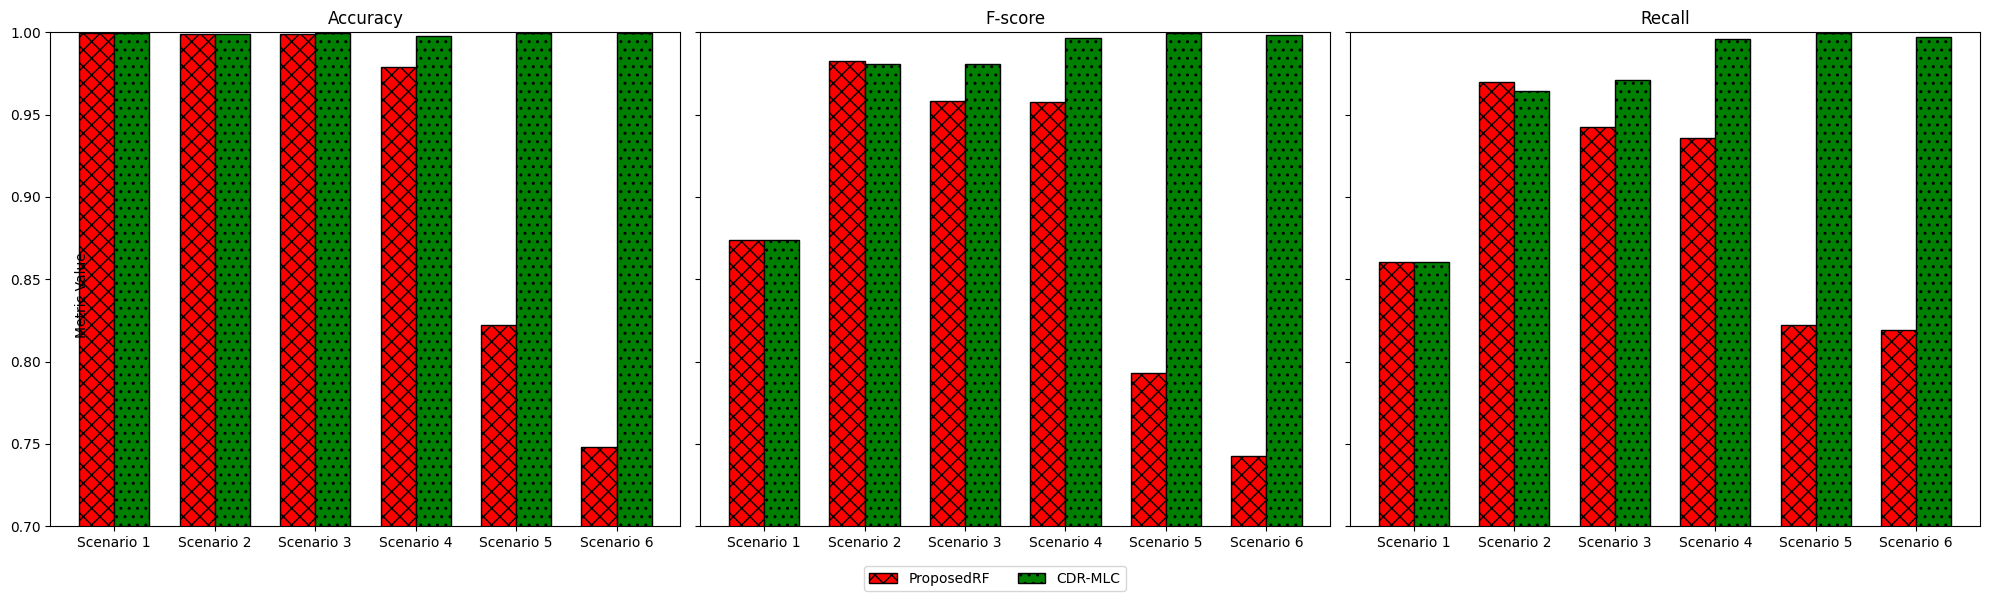

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data for each scenario
scenarios = ['Scenario 1', 'Scenario 2', 'Scenario 3', 'Scenario 4', 'Scenario 5', 'Scenario 6']
accuracy = {
    'ProposedRF': [0.9993, 0.9992, 0.9989, 0.9790, 0.8221, 0.7481],
    'CDR-MLC': [0.9993, 0.9991, 0.9996, 0.9980, 0.9994, 0.9998]
}
f_score = {
    'ProposedRF': [0.8737, 0.9828, 0.9581, 0.9579, 0.7929, 0.7429],
    'CDR-MLC': [0.8737, 0.9806, 0.9809, 0.9964, 0.9994, 0.9986]
}
recall = {
    'ProposedRF': [0.8606, 0.9697, 0.9427, 0.9358, 0.8224, 0.8191],
    'CDR-MLC': [0.8606, 0.9643, 0.9712, 0.9957, 0.9994, 0.9973]
}

# Plotting all three metrics horizontally
fig, axs = plt.subplots(1, 3, figsize=(20, 6), sharey=True)  # 1 row, 3 columns layout

# Bar width for each plot
bar_width = 0.35
index = np.arange(len(scenarios))

# Plot for Accuracy
bar1 = axs[0].bar(index, accuracy['ProposedRF'], bar_width, label='ProposedRF', color='red', edgecolor='black', hatch='xx')
bar2 = axs[0].bar(index + bar_width, accuracy['CDR-MLC'], bar_width, label='CDR-MLC', color='green', edgecolor='black', hatch='..')
axs[0].set_title('Accuracy')
axs[0].set_xticks(index + bar_width / 2)
axs[0].set_xticklabels(scenarios)
axs[0].set_ylim(0.6, 1)

# Plot for F-score
bar1 = axs[1].bar(index, f_score['ProposedRF'], bar_width, label='ProposedRF', color='red', edgecolor='black', hatch='xx')
bar2 = axs[1].bar(index + bar_width, f_score['CDR-MLC'], bar_width, label='CDR-MLC', color='green', edgecolor='black', hatch='..')
axs[1].set_title('F-score')
axs[1].set_xticks(index + bar_width / 2)
axs[1].set_xticklabels(scenarios)
axs[1].set_ylim(0.6, 1)

# Plot for Recall
bar1 = axs[2].bar(index, recall['ProposedRF'], bar_width, label='ProposedRF', color='red', edgecolor='black', hatch='xx')
bar2 = axs[2].bar(index + bar_width, recall['CDR-MLC'], bar_width, label='CDR-MLC', color='green', edgecolor='black', hatch='..')
axs[2].set_title('Recall')
axs[2].set_xticks(index + bar_width / 2)
axs[2].set_xticklabels(scenarios)
axs[2].set_ylim(0.7, 1)

# Set y-label for the entire figure
fig.text(0.04, 0.5, 'Metric Value', va='center', rotation='vertical')

# Adding a common legend at the bottom
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)

plt.tight_layout(rect=[0, 0.05, 1, 1])  # Adjust layout to make space for the legend
plt.show()
